In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
df = pd.read_csv('final_chess.csv',index_col =[0])
df

C:\Users\miche\anaconda3\lib\site-packages\numpy\lib\arraysetops.py:583: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  mask |= (ar1 == a)


,WHITE,BLACK,RESULT,DATE,MOVES,B_ELO,W_ELO
0,?,?,*,????.??.??,"['e4', 'c5', 'Nf3', 'e6', 'd4', 'cxd4', 'Nxd4'...",2804.0,2666.0
1,"Naroditsky, Daniel","Hansen, Eric",1-0,????.??.??,NaN,2606.0,2621.0
2,"Naroditsky, Daniel","Hansen, Eric",1-0,????.??.??,NaN,2606.0,2621.0
3,"Ritsema, Ronald","Noomen, Jeroen",0-1,????.??.??,"['c4', 'Nf6', 'Nc3', 'e5', 'Nf3', 'Nc6', 'g3',...",NaN,2633.0
4,"Fressinet, Laurent","Argandona Riveiro, Inigo",1-0,????.06.11,"['d4', 'd5', 'c4', 'dxc4', 'Nf3', 'a6', 'e3', ...",2382.0,2461.0
...,...,...,...,...,...,...,...
3691276,"Andersson, S","Andersson, Ka",1/2-1/2,2010.07.07,"['d4', 'd5', 'Nf3', 'Nf6', 'g3', 'g6', 'Bg2', ...",2098.0,2392.0
3691277,"Lyell, M..","Lengyel, Bela",1/2-1/2,2010.07.07,"['e4', 'e5', 'f4', 'exf4', 'Nf3', 'Be7', 'Nc3'...",2257.0,2392.0
3691278,"Lyell, M.","Lengyel, Bela",1/2-1/2,2010.07.07,"['e4', 'e5', 'f4', 'exf4', 'Nf3', 'Be7', 'Nc3'...",2257.0,2211.0
3691279,"Wahlbom, Magnus","Axelsson, Uno",1-0,2010.07.07,"['e4', 'e6', 'd4', 'd5', 'Nd2', 'Nf6', 'e5', '...",NaN,2224.0


In [3]:
df = df[df['MOVES'].notna()]

In [4]:
alg = df['MOVES'].to_list()

A regex expression is used to retrieve all the checkmates

In [6]:
pattern = r'(\w+\#)'

In [8]:
check_mates = []

In [10]:
for s in alg:
    res= re.findall(pattern,s)
    
    if len(res) == 1:
        check_mates.append(res[0])
    elif len(res) > 0:
        for i in range(len(res)):
            check_mates.append(res[i])

In [14]:
len(check_mates)

51040

Counters for every single piece

In [13]:
K = 0
Q = 0
R = 0
N = 0
B = 0
p = 0

Updating counters

In [18]:
for c in check_mates:
    if c[0].isupper:
        if c[0] == 'K':
            K += 1
        elif c[0] == 'Q':
            Q += 1
        elif c[0] == 'R':
            R += 1
        elif c[0] == 'N':
            N += 1
        else:
            B += 1
    else:
        p += 1
            

In [28]:
K

21

In [29]:
y = [Q,R,B,N,K]

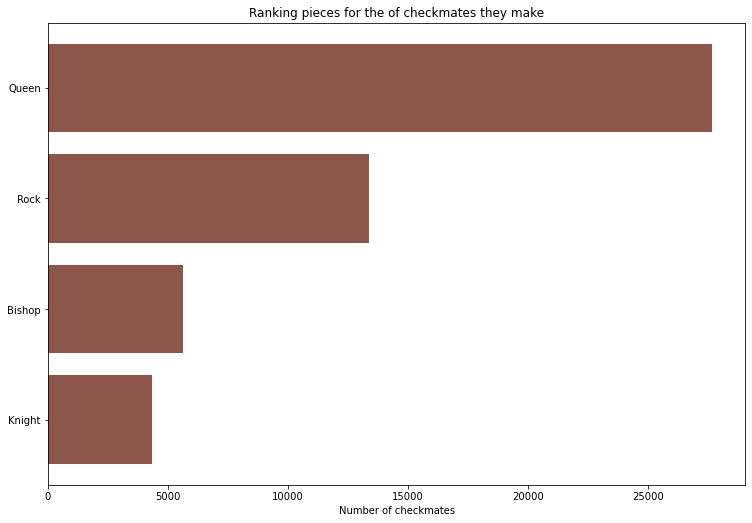

In [52]:
fig, ax = plt.subplots()

y = ['Queen','Rock','Bishop','Knight']
x = [Q,R,B,N]
y_pos = np.arange(len(y))

fig.set_size_inches(12.5, 8.5)
ax.barh(y_pos, x, color='tab:brown')
ax.set_yticks(y_pos)
ax.set_yticklabels(y)
ax.invert_yaxis()  # labels read top-to-bottom
ax.set_xlabel('Number of checkmates')
ax.set_title('Ranking pieces for the of checkmates they make')
fig.savefig('check_mates.png', dpi=100)

plt.show()